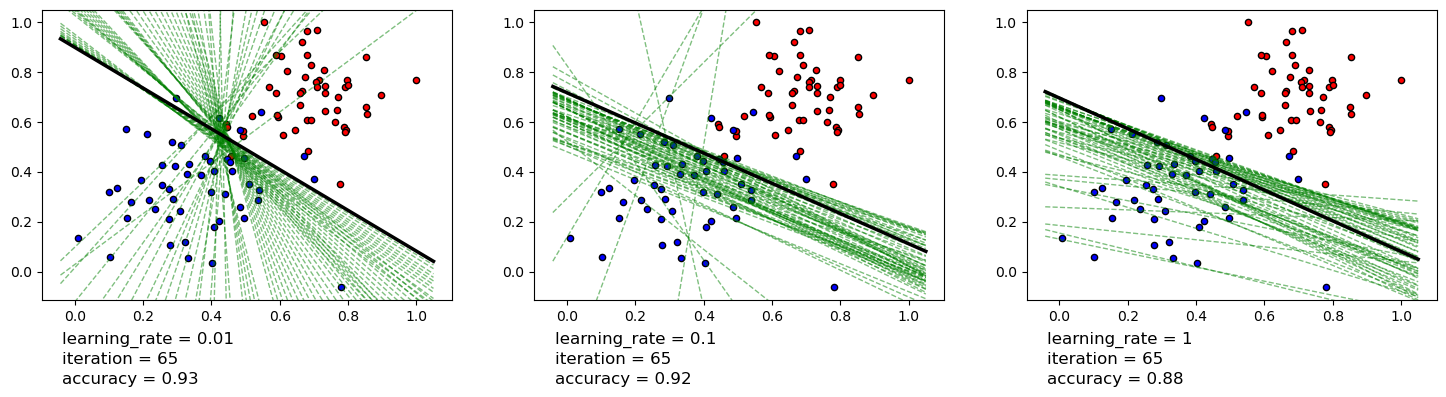

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv", header=None)
X = df.iloc[:, :2].values
y = df.iloc[:, 2].values

def train_and_plot(ax, lr):
    np.random.seed(42)
    w = np.random.uniform(-1, 1, 2)
    b = np.random.uniform(-1, 1)
    
    ax.scatter(X[y == 0][:, 0], X[y == 0][:, 1], c="red", edgecolors="black", s=20)
    ax.scatter(X[y == 1][:, 0], X[y == 1][:, 1], c="blue", edgecolors="black", s=20)
    
    x_vals = np.array([X[:, 0].min() - 0.05, X[:, 0].max() + 0.05])
    
    y_vals = -(w[0] * x_vals + b) / w[1]
    ax.plot(x_vals, y_vals, color="red", linestyle="-", linewidth=2)

    for _ in range(65):
        for i in range(len(X)):
            y_pred = 1 if np.dot(w, X[i]) + b >= 0 else 0
            if y_pred != y[i]:
                if y_pred == 0:
                    b += lr
                    w += lr * X[i]
                else:
                    b -= lr
                    w -= lr * X[i]
                    
        y_vals = -(w[0] * x_vals + b) / w[1]
        ax.plot(x_vals, y_vals, color="green", linestyle="--", linewidth=1, alpha=0.5)

    y_vals = -(w[0] * x_vals + b) / w[1]
    ax.plot(x_vals, y_vals, color="black", linestyle="-", linewidth=2.5)

    correct = 0
    for i in range(len(X)):
        if (1 if np.dot(w, X[i]) + b >= 0 else 0) == y[i]:
            correct += 1
    acc = correct / len(X)

    ax.set_ylim(X[:, 1].min() - 0.05, X[:, 1].max() + 0.05)
    ax.text(0.05, -0.15, f"learning_rate = {lr}", transform=ax.transAxes, fontsize=12)
    ax.text(0.05, -0.22, f"iteration = 65", transform=ax.transAxes, fontsize=12)
    ax.text(0.05, -0.29, f"accuracy = {acc:.2f}", transform=ax.transAxes, fontsize=12)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
lrs = [0.01, 0.1, 1]

for i in range(3):
    train_and_plot(axes[i], lrs[i])

plt.subplots_adjust(bottom=0.3)
plt.show()

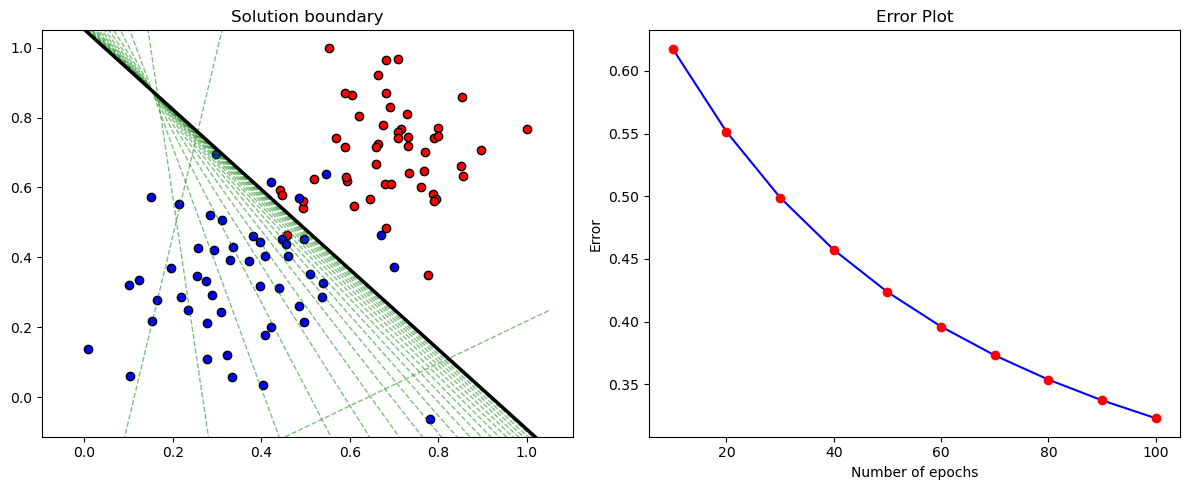

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv", header=None).values
X, y = df[:, :2], df[:, 2]
S = lambda z: 1 / (1 + np.exp(-z))

np.random.seed(42)
w, b = np.random.uniform(-1, 1, 2), np.random.uniform(-1, 1)
lr, epochs = 0.01, 100
x = np.array([X[:,0].min()-0.05, X[:,0].max()+0.05])
errs = []

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(*X[y==0].T, c="red", ec="k")
ax1.scatter(*X[y==1].T, c="blue", ec="k")

draw = lambda c, ls, lw, a=1: ax1.plot(x, -(w[0]*x+b)/w[1], c=c, ls=ls, lw=lw, alpha=a)

draw("red", "-", 2)
for e in range(epochs):
    for xi, yi in zip(X, y):
        err = yi - S(w @ xi + b)
        w, b = w + lr*err*xi, b + lr*err
    if e % 5 == 0: draw("green", "--", 1, 0.5)
    if (e+1) % 10 == 0:
        yhat = S(X @ w + b)
        errs.append(-np.mean(y*np.log(yhat+1e-9) + (1-y)*np.log(1-yhat+1e-9)))
draw("black", "-", 2.5)

ax1.set(title="Solution boundary", ylim=(X[:,1].min()-0.05, X[:,1].max()+0.05))
ep = range(10, epochs+1, 10)
ax2.plot(ep, errs, "b-")
ax2.scatter(ep, errs, c="red", zorder=5)
ax2.set(title="Error Plot", xlabel="Number of epochs", ylabel="Error")

plt.tight_layout()
plt.show()